# Comparing the two models

`01_naive_bayes.ipynb` and `02_neural_network.ipynb` were written separately, but they load the
same file and split it the same way - `test_size=0.2`, `stratify=y`, `random_state=42`. That means
they were scored on exactly the same test rows, so the two accuracies can be compared directly.

This notebook rebuilds both on that split, adds the majority-class baseline, and looks at what the
comparison says about the data.

## Same split, both feature sets

Naive Bayes used one-hot encoding only. The network also scaled the numeric columns. Both are
built here so nothing is carried over from the other notebooks.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv('Train.csv')

X = df.drop(columns=['ID', 'Reached.on.Time_Y.N'])
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
num_cols = [c for c in X_train.columns if c not in cat_cols]

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])
train_cat = encoder.transform(X_train[cat_cols])
test_cat = encoder.transform(X_test[cat_cols])

# Naive Bayes input: one-hot only
nb_train = np.hstack([X_train[num_cols].to_numpy(), train_cat])
nb_test = np.hstack([X_test[num_cols].to_numpy(), test_cat])

# Network input: same, with the numeric columns scaled
scaler = StandardScaler()
scaler.fit(X_train[num_cols])
mlp_train = np.hstack([scaler.transform(X_train[num_cols]), train_cat])
mlp_test = np.hstack([scaler.transform(X_test[num_cols]), test_cat])

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print('Test rows:', len(y_test))
print('Test class balance:', np.bincount(y_test))

Test rows: 2200
Test class balance: [ 887 1313]


## The three models

The network uses the configuration the search in `02_neural_network.ipynb` picked - 2 hidden
layers of 16 units, L1/L2 = 0.001 - so no search is repeated here.

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score

baseline = DummyClassifier(strategy='most_frequent').fit(nb_train, y_train)
base_pred = baseline.predict(nb_test)

gnb = GaussianNB().fit(nb_train, y_train)
gnb_pred = gnb.predict(nb_test)

print('Baseline  :', round(accuracy_score(y_test, base_pred), 4))
print('GaussianNB:', round(accuracy_score(y_test, gnb_pred), 4))

Baseline  : 0.5968
GaussianNB: 0.6441


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

np.random.seed(42)
tf.random.set_seed(42)

reg = regularizers.l1_l2(l1=1e-3, l2=1e-3)
mlp = keras.Sequential([
    layers.Input(shape=(mlp_train.shape[1],)),
    layers.Dense(16, activation='relu', kernel_regularizer=reg),
    layers.Dense(16, activation='relu', kernel_regularizer=reg),
    layers.Dense(1, activation='sigmoid'),
])
mlp.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
mlp.fit(mlp_train, y_train, epochs=30, batch_size=32, verbose=0)

mlp_pred = (mlp.predict(mlp_test, verbose=0) > 0.5).astype(int).ravel()
print('MLP       :', round(accuracy_score(y_test, mlp_pred), 4))

I0000 00:00:1788846468.057755    2152 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788846468.479308    2152 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788846470.916328    2152 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


MLP       : 0.6718


The network lands at 67.2% here against 67.1% in `02_neural_network.ipynb`. The baseline and
GaussianNB numbers match to four decimal places.

That difference is not a bug, and it is not about the machine. GaussianNB has a **closed form** -
it computes a mean and variance per column and stops, so once the split is fixed there is nothing
left to vary. The network is fitted by **iterative optimisation**: it starts from random weights
and moves in steps. `set_seed` pins the weight initialisation and the batch shuffling, but not the
order in which multi-threaded operations accumulate their sums - and floating point addition is not
associative, so a different summation order gives a slightly different number. Pinning that too
needs `tf.config.experimental.enable_op_determinism()`, at a cost in speed.

## Side by side

Accuracy alone is not enough here, but neither is recall. Both are reported below along with
precision, and with the count of orders each model actually flags as late - which is what a
warehouse would have to act on.

In [4]:
from sklearn.metrics import classification_report, precision_score, f1_score

for name, pred in [('Majority baseline', base_pred), ('GaussianNB', gnb_pred), ('Neural network', mlp_pred)]:
    print('=====', name)
    print(classification_report(y_test, pred, target_names=['on time', 'late'], zero_division=0))

===== Majority baseline
              precision    recall  f1-score   support

     on time       0.00      0.00      0.00       887
        late       0.60      1.00      0.75      1313

    accuracy                           0.60      2200
   macro avg       0.30      0.50      0.37      2200
weighted avg       0.36      0.60      0.45      2200

===== GaussianNB
              precision    recall  f1-score   support

     on time       0.53      0.97      0.69       887
        late       0.96      0.42      0.59      1313

    accuracy                           0.64      2200
   macro avg       0.74      0.70      0.64      2200
weighted avg       0.78      0.64      0.63      2200

===== Neural network
              precision    recall  f1-score   support

     on time       0.56      0.91      0.69       887
        late       0.89      0.51      0.65      1313

    accuracy                           0.67      2200
   macro avg       0.73      0.71      0.67      2200
weighted avg

In [5]:
rows = []
for name, pred in [('Majority baseline', base_pred), ('GaussianNB', gnb_pred), ('Neural network', mlp_pred)]:
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'recall_late': recall_score(y_test, pred, pos_label=1),
        'precision_late': precision_score(y_test, pred, pos_label=1, zero_division=0),
        'f1_late': f1_score(y_test, pred, pos_label=1, zero_division=0),
        'flagged_late': int(pred.sum()),
    })

results = pd.DataFrame(rows).set_index('model').round(4)
results

,accuracy,recall_late,precision_late,f1_late,flagged_late
model,,,,,
Majority baseline,0.5968,1.0000,0.5968,0.7475,2200
GaussianNB,0.6441,0.4235,0.9553,0.5868,582
Neural network,0.6718,0.5103,0.8945,0.6499,749


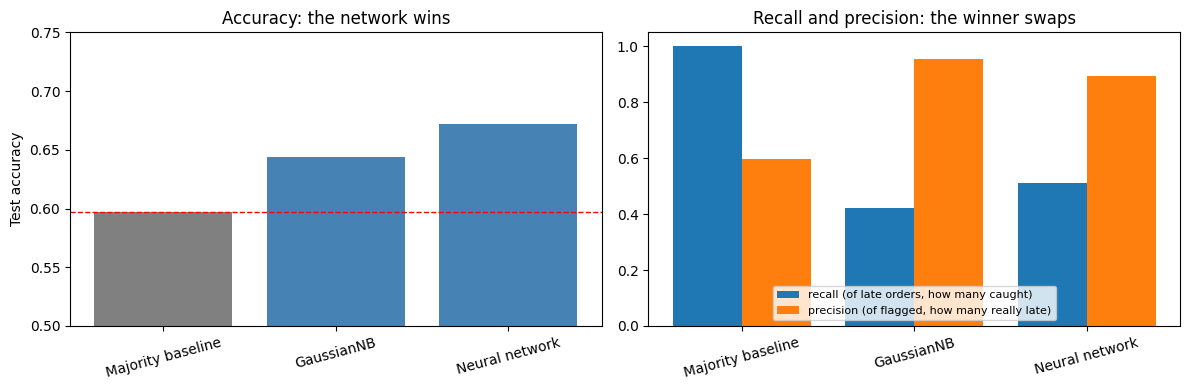

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(results))

axes[0].bar(results.index, results['accuracy'], color=['grey', 'steelblue', 'steelblue'])
axes[0].axhline(results.loc['Majority baseline', 'accuracy'], color='red', linestyle='--', linewidth=1)
axes[0].set_ylim(0.5, 0.75)
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Accuracy: the network wins')

axes[1].bar(x - 0.2, results['recall_late'], 0.4, label='recall (of late orders, how many caught)')
axes[1].bar(x + 0.2, results['precision_late'], 0.4, label='precision (of flagged, how many really late)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results.index)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8, loc='lower center')
axes[1].set_title('Recall and precision: the winner swaps')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## So what

**Every metric picks a different winner.** Accuracy says the network. Recall on late orders says
the majority baseline - it catches all of them, because it calls everything late. Precision says
GaussianNB, which is right 95% of the times it speaks up. Even F1 ranks the baseline first. A model
that has learned nothing tops two of the four columns, which is the clearest possible sign that no
single number decides this.

**The answer comes from the cost structure, not from the metric.** The real question is what it
costs to be wrong in each direction. If acting on a warning is free, flag every order and be done -
the baseline is optimal. If only a limited number of orders can be chased, then the model that
names about 750 of them and is right roughly 90% of the time is worth far more than one that
names all 2,200 and is right 60% of the time. **"Which model is best" cannot be answered before knowing the ratio between the
cost of missing a late order and the cost of chasing an on-time one.** That ratio is a business
input, not something in this dataset.

**And the ceiling is in the features.** Separately from the choice above: the baseline gets 59.7%
for free, Naive Bayes adds about 5 points, and a neural network with no independence assumption,
tuned over 8 configurations, adds about 3 more and stops. Two model families with very different
assumptions landing that close together says the limit is the information in the columns. There is
no route, carrier, distance or season here, and `Discount_offered` was the one feature that visibly
separated the classes. More features would move this further than more tuning.

## Limitations

- One train/test split with a fixed seed. Cross-validation would give an error range instead of
  single numbers, and would say whether the gap between the two models is real.
- The decision threshold is fixed at 0.5 throughout. Since the conclusion above turns on the
  precision/recall trade, the honest next step is a threshold sweep once the cost ratio is known -
  the threshold, not the model, is the dial that moves that trade.
- The dataset is a single snapshot with no dates, so nothing here says whether the pattern holds
  over time.